# Data

In [7]:
from torchvision import datasets
import os
import kagglehub

# Download latest version
DATA_PATH = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")
IMG_PATH = os.path.join(DATA_PATH, "images", "Images")
ANNOTATION_PATH = os.path.join(DATA_PATH, "annotations", "Annotations")

print("Path to dataset files:", DATA_PATH)

dataset = datasets.ImageFolder(root=IMG_PATH)

Path to dataset files: /home/franio/.cache/kagglehub/datasets/jessicali9530/stanford-dogs-dataset/versions/2


# Model, Transform and Prediction

In [8]:
import torch
from utils.model_eval import test_on_given_idx
from torchvision.models import resnet
from torchvision import transforms
import numpy as np

#Setting seeds
np.random.seed(42)
torch.manual_seed(42)

MODEL_NAME = 'resnet18_dogs_5_epochs'

net_model = resnet.resnet18()
net_model.load_state_dict(torch.load(os.path.join('models', f"{MODEL_NAME}.pth"), weights_only=True))

#transforms for prediction
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
transform = transforms.Compose([transforms.Resize((224,224)),
                                         transforms.ToTensor(),
                                         transforms.Normalize(mean, std)])

idx = np.random.choice(np.arange(start=0, stop=len(dataset)), size=6, replace=False)
preds, df = test_on_given_idx(dataset, net_model,transform, idx=idx)
df

,Idx,True_Label,Predicted_Label
0,16226,n02109047-Great_Dane,n02109047-Great_Dane
1,3388,n02090622-borzoi,n02090622-borzoi
2,20011,n02113978-Mexican_hairless,n02113978-Mexican_hairless
3,1427,n02087046-toy_terrier,n02087046-toy_terrier
4,19697,n02113712-miniature_poodle,n02113712-miniature_poodle
5,5883,n02093859-Kerry_blue_terrier,n02093859-Kerry_blue_terrier


# Plot Images

array([16226,  3388, 20011,  1427, 19697,  5883])

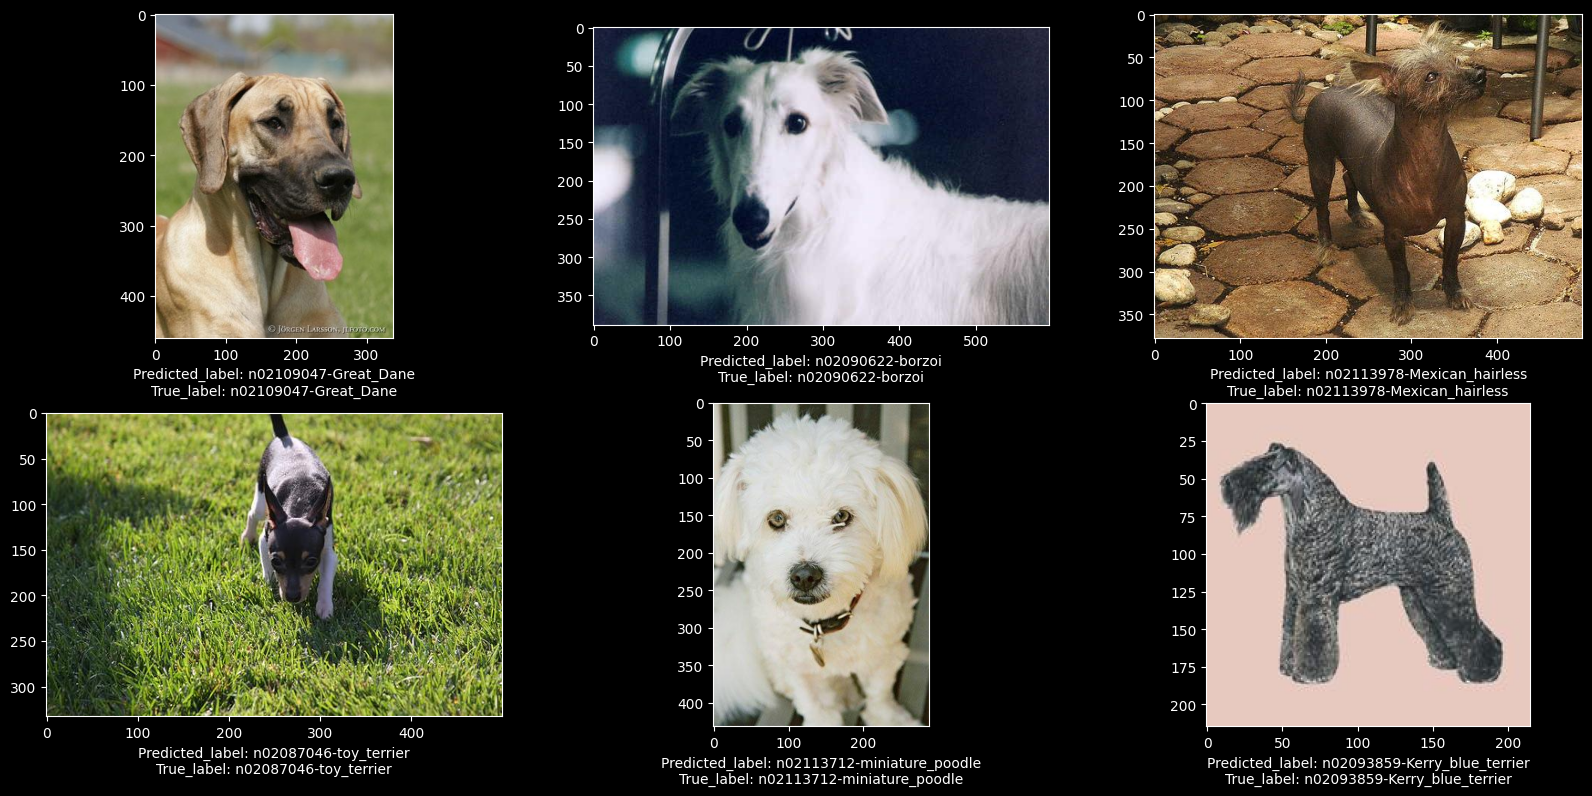

In [12]:
from utils.plot import plot_idx_labeled

plot_idx_labeled(idx,preds,dataset)

# Explanation via LIME
The Default algorithm for calculating superpixels in lime library is [quickshift](https://scikit-image.org/docs/0.24.x/auto_examples/segmentation/plot_segmentations.html#quickshift-image-segmentation).

## Predict function, Images and Targets

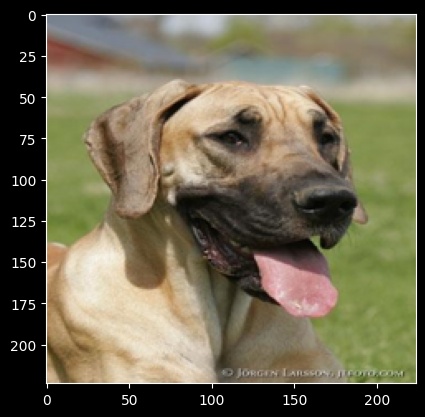

,classes,preds
0,n02109047-Great_Dane,1.000000e+00
1,n02108422-bull_mastiff,3.826057e-08
2,n02105162-malinois,7.758889e-12
3,n02091134-whippet,6.776297e-12
4,n02108089-boxer,6.661068e-12


In [13]:
import matplotlib.pyplot as plt
from utils.model_eval import get_top_k_predictions
import torch.nn.functional as F

def batch_predict(images:np.ndarray) -> np.ndarray:
    predict_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)])


    net_model.cpu().eval()
    batch = torch.stack([predict_transform(img) for img in images], dim=0)
    logits = net_model(batch)

    batch_probs = F.softmax(logits, dim=1)
    return batch_probs.detach().numpy()

imgs = np.array([np.array(dataset[i][0].resize((224, 224))) for i in idx])
targets = np.array([dataset[i][1] for i in idx])


plt.imshow(imgs[0])
plt.show()


probs = batch_predict(np.array([imgs[0]]))[0]
probs_df = get_top_k_predictions(probs, dataset.classes, k=5)

probs_df

## LIME explanation
For one image for now

In [22]:
from lime import lime_image
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(imgs[0], batch_predict, top_labels=5, hide_color=0, num_samples=1000)


100%|██████████| 1000/1000 [00:19<00:00, 51.87it/s]


### Areas encouraging top prediction

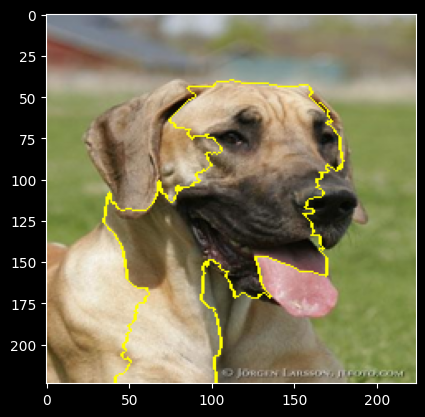

In [23]:
from skimage.segmentation import mark_boundaries

temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
img_boundry1 = mark_boundaries(temp/255.0, mask)
plt.imshow(img_boundry1)
plt.show()

### areas that contributes for and against the top prediction.

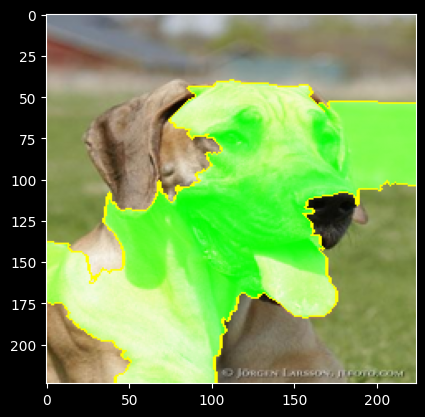

In [24]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=10, hide_rest=False)
img_boundry2 = mark_boundaries(temp/255.0, mask)
plt.imshow(img_boundry2)
plt.show()

# Explaining all images

In [26]:
explanations = []
for img in imgs:
    explanations.append(explainer.explain_instance(img, batch_predict, top_labels=5, hide_color=0, num_samples=100))

explanations

100%|██████████| 100/100 [00:02<00:00, 40.50it/s]


## Vizualize

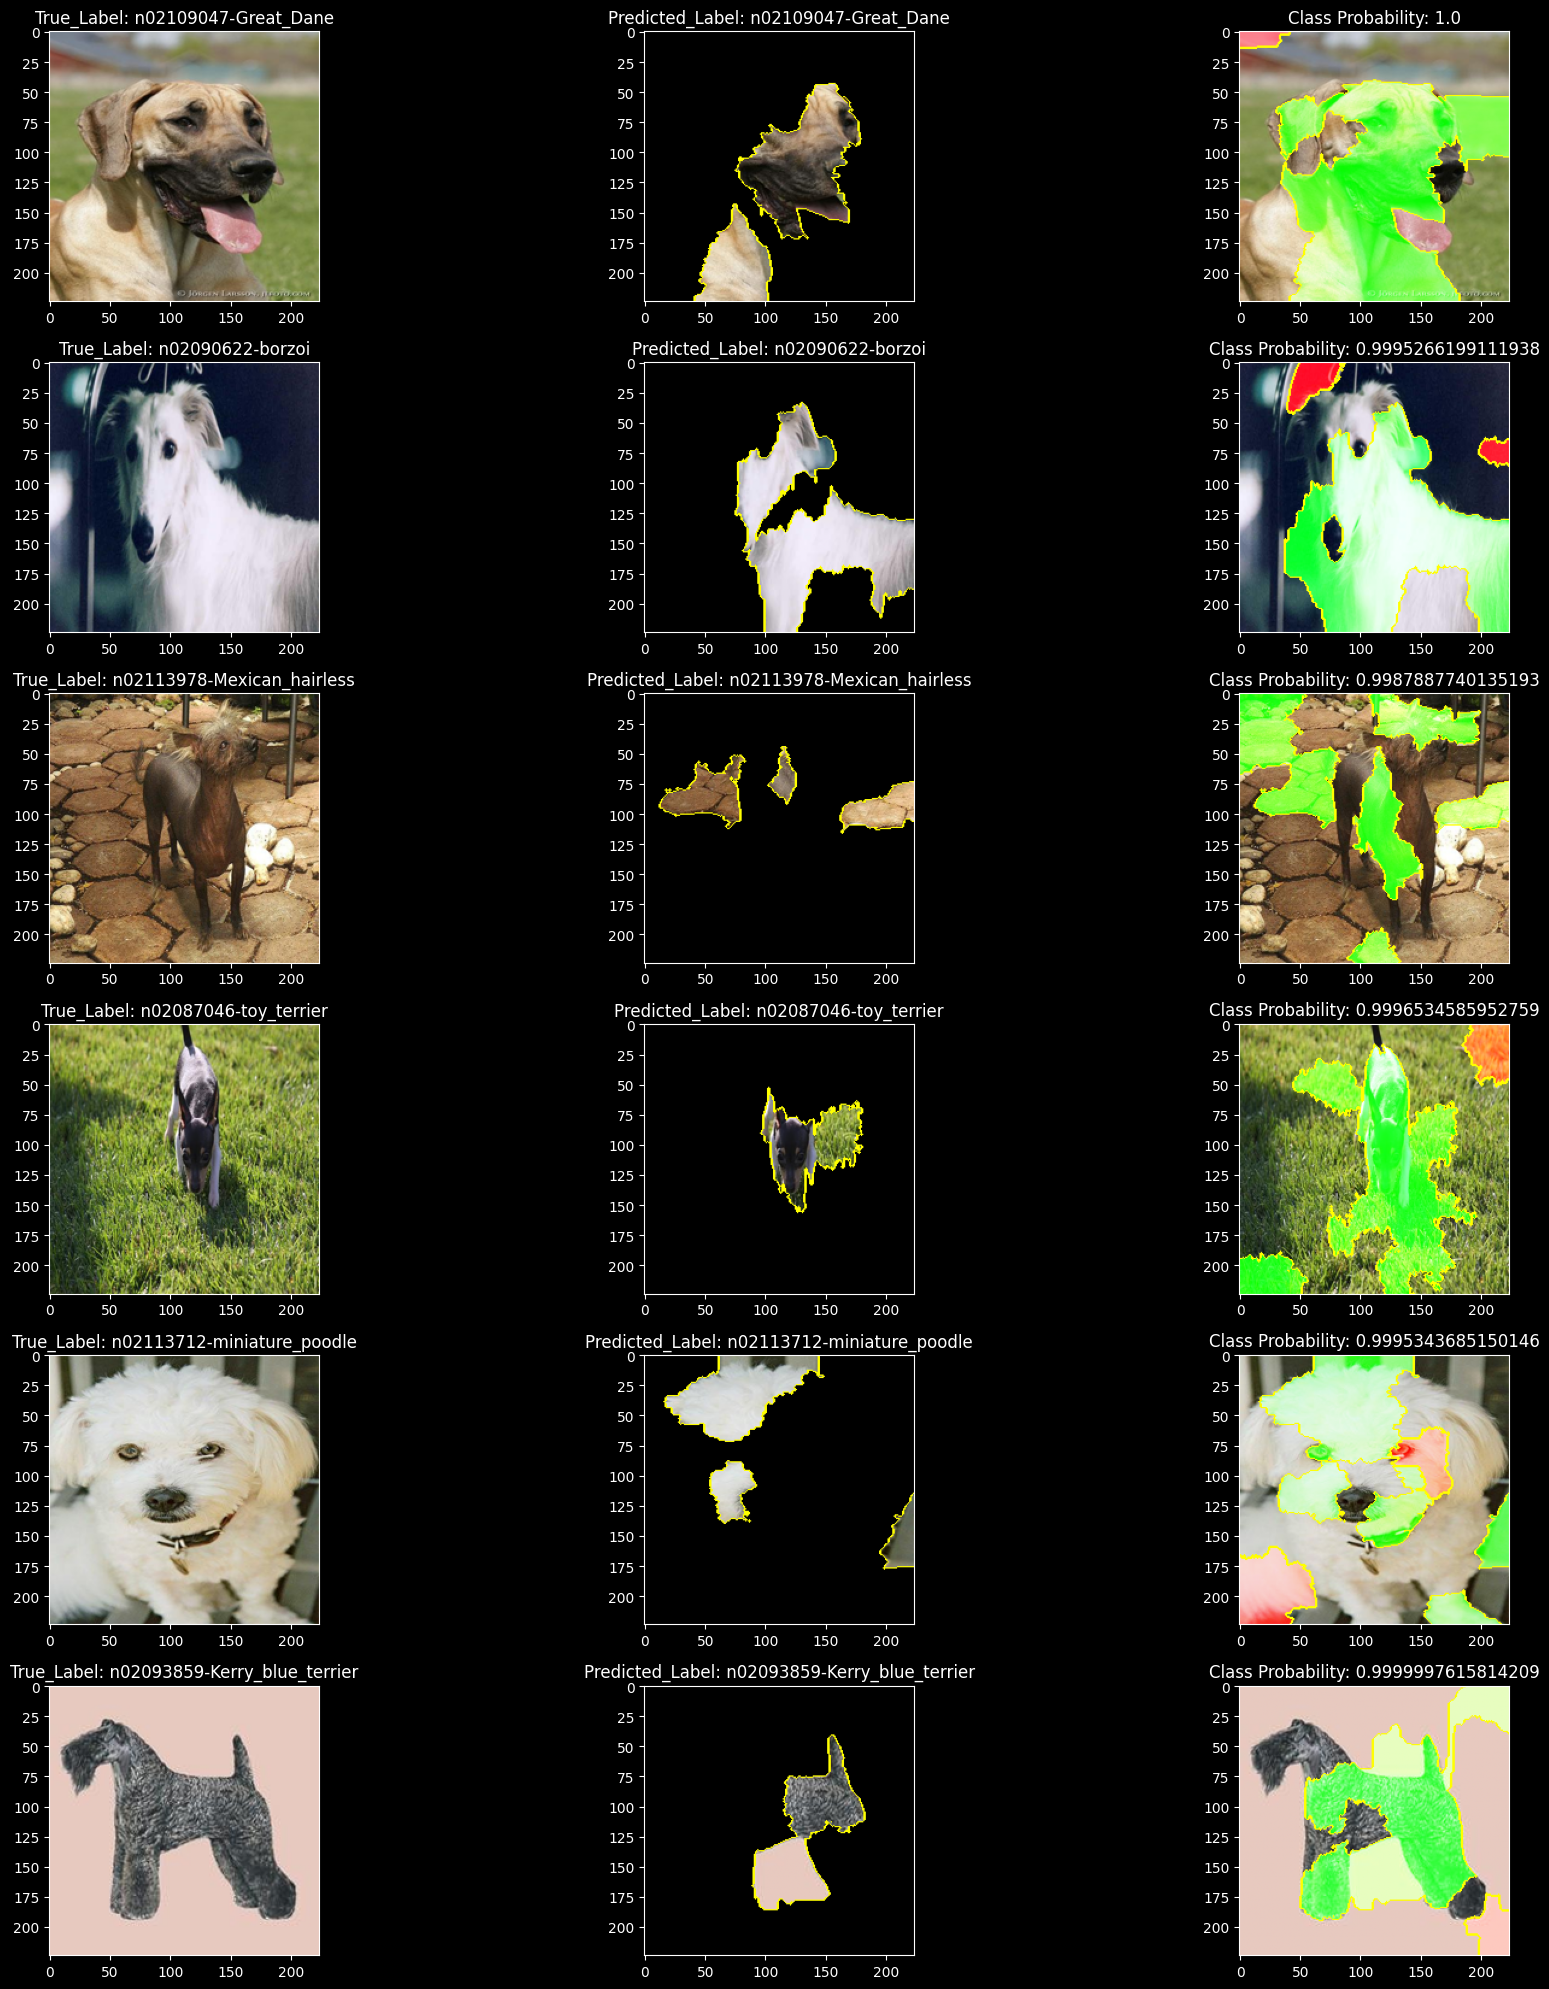

In [62]:
probs = batch_predict(imgs)
best_idx = [np.argsort(p)[::-1][0] for p in probs]
best_probs = [p[best_idx[i]] for i, p in enumerate(probs)]


fig, axs = plt.subplots(6,3, figsize = (20,20))
for idx, current_ex in enumerate(explanations):
    axs[idx, 0].imshow(imgs[idx])
    axs[idx, 0].set_title(f"True_Label: {df['True_Label'].iloc[idx]}")

    temp, mask = current_ex.get_image_and_mask(current_ex.top_labels[0], positive_only=True, num_features=3, hide_rest=True)
    img_boundry2 = mark_boundaries(temp/255.0, mask)
    axs[idx, 1].imshow(img_boundry2)
    axs[idx, 1].set_title(f"Predicted_Label: {df['Predicted_Label'].iloc[idx]}")

    temp, mask = current_ex.get_image_and_mask(current_ex.top_labels[0], positive_only=False, num_features=10, hide_rest=False)
    img_boundry2 = mark_boundaries(temp/255.0, mask)
    axs[idx, 2].imshow(img_boundry2)
    axs[idx, 2].set_title(f"Class Probability: {best_probs[idx]}")

fig.tight_layout()
plt.show()